# Линейная регрессия на датасете Diabetes

## Цель

Задача регрессии: по медицинским признакам пациента предсказать числовой показатель
прогрессирования диабета через год после обследования.

## Кратко о линейной регрессии

Линейная регрессия описывает целевую переменную как линейную комбинацию признаков.
Каждому признаку соответствует коэффициент. Знак коэффициента задаёт направление влияния,
модуль коэффициента задаёт силу влияния при прочих равных.

Схема модели:

`target = b0 + b1 * x1 + b2 * x2 + ... + bn * xn`


## О датасете Diabetes

Датасет `Diabetes` из `scikit-learn` содержит `442` наблюдения и `10` числовых признаков.
Целевая переменная `target` - количественная мера прогрессирования болезни.

Краткое описание признаков:

- `age` - возраст пациента.
- `sex` - пол пациента.
- `bmi` - индекс массы тела.
- `bp` - среднее артериальное давление.
- `s1` - общий холестерин.
- `s2` - липопротеины низкой плотности.
- `s3` - липопротеины высокой плотности.
- `s4` - отношение общего холестерина к HDL.
- `s5` - логарифм уровня триглицеридов.
- `s6` - уровень глюкозы в крови.


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

diabetes = load_diabetes()
df_diabetes = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df_diabetes["target"] = diabetes.target

print(f"Размер датасета: {df_diabetes.shape}")
display(df_diabetes.head(10))


Размер датасета: (442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
5,-0.092695,-0.044642,-0.040696,-0.019442,-0.068991,-0.079288,0.041277,-0.076395,-0.041176,-0.096346,97.0
6,-0.045472,0.050680,-0.047163,-0.015999,-0.040096,-0.024800,0.000779,-0.039493,-0.062917,-0.038357,138.0
7,0.063504,0.050680,-0.001895,0.066629,0.090620,0.108914,0.022869,0.017703,-0.035816,0.003064,63.0
8,0.041708,0.050680,0.061696,-0.040099,-0.013953,0.006202,-0.028674,-0.002592,-0.014960,0.011349,110.0
9,-0.070900,-0.044642,0.039062,-0.033213,-0.012577,-0.034508,-0.024993,-0.002592,0.067737,-0.013504,310.0


## Первичный анализ данных

Проверяются типы данных, наличие пропусков и диапазоны значений признаков.


In [26]:
print("Информация о датасете:\n")
df_diabetes.info()

print("\nОписательная статистика:\n")
display(df_diabetes.describe())


Информация о датасете:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB

Описательная статистика:



,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


## Корреляционный анализ

Тепловая карта показывает связи признаков между собой и с `target`.
Отдельная таблица ниже показывает корреляцию каждого признака с целевой переменной.


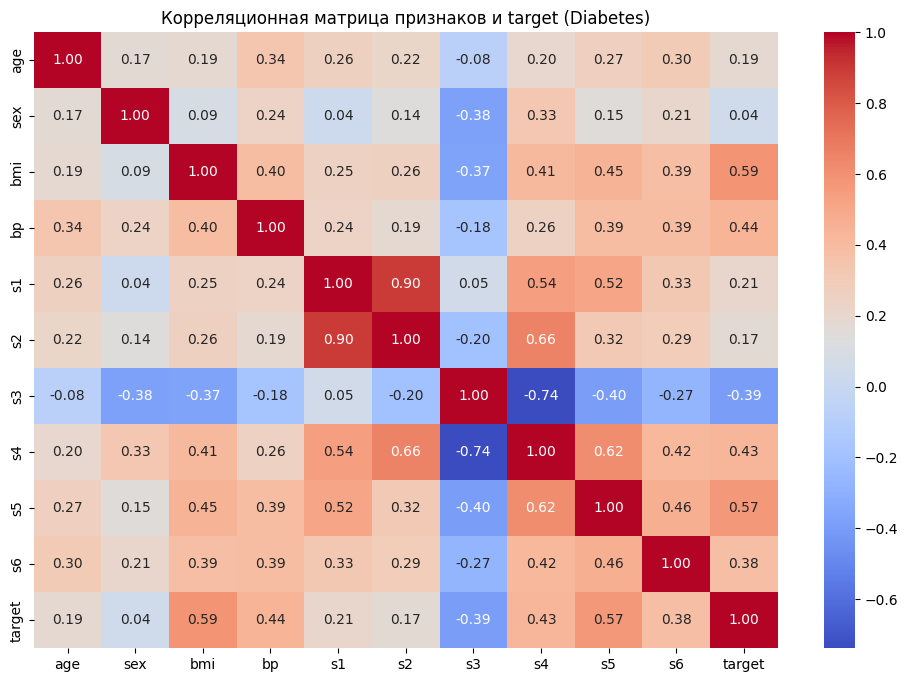

Корреляция признаков с target:


,target
target,1.000000
bmi,0.586450
s5,0.565883
bp,0.441482
s4,0.430453
s6,0.382483
s1,0.212022
age,0.187889
s2,0.174054
sex,0.043062


In [27]:
plt.figure(figsize=(12, 8))
corr_matrix = df_diabetes.corr(numeric_only=True)

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Корреляционная матрица признаков и target (Diabetes)")
plt.show()

target_corr = corr_matrix[["target"]].sort_values(by="target", ascending=False)
print("Корреляция признаков с target:")
display(target_corr)


## Подготовка данных

Данные делятся на обучающую и тестовую выборки.
После разбиения выполняется стандартизация признаков.


In [28]:
X = df_diabetes.drop(columns=["target"])
y = df_diabetes["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Размер train: {X_train.shape}")
print(f"Размер test: {X_test.shape}")


Размер train: (353, 10)
Размер test: (89, 10)


## Обучение модели

Обучается модель `LinearRegression` на подготовленной обучающей выборке.


In [29]:
linreg = LinearRegression()
linreg.fit(X_train_scaled, y_train)


LinearRegression()

## Метрики и коэффициенты

Рассчитываются `MSE`, `MAE`, `MAPE` и `R^2`.
Также выводятся коэффициенты модели.

Интерпретация метрик:

- `MSE` и `MAE` отражают абсолютную величину ошибки.
- `MAPE` отражает относительную ошибку.
- `R^2` показывает долю вариации `target`, которую объясняет модель.

Интерпретация коэффициентов:

- положительный коэффициент соответствует росту прогноза при увеличении признака;
- отрицательный коэффициент соответствует снижению прогноза при увеличении признака.


In [30]:
y_pred = linreg.predict(X_test_scaled)

metrics_df = pd.DataFrame(
    {
        "Метрика": ["MSE", "MAE", "MAPE", "R^2"],
        "Значение": [
            mean_squared_error(y_test, y_pred),
            mean_absolute_error(y_test, y_pred),
            mean_absolute_percentage_error(y_test, y_pred),
            r2_score(y_test, y_pred),
        ],
    }
)

coef_df = pd.DataFrame(
    {
        "feature": X.columns,
        "coefficient": linreg.coef_,
    }
)
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values(by="abs_coefficient", ascending=False)

display(metrics_df)
display(coef_df)


,Метрика,Значение
0,MSE,2900.193628
1,MAE,42.794095
2,MAPE,0.374998
3,R^2,0.452603


,feature,coefficient,abs_coefficient
4,s1,-44.448856,44.448856
8,s5,35.161195,35.161195
2,bmi,25.607121,25.607121
5,s2,24.640954,24.640954
3,bp,16.828872,16.828872
7,s4,13.138784,13.138784
1,sex,-11.511809,11.511809
6,s3,7.676978,7.676978
9,s6,2.351364,2.351364
0,age,1.753758,1.753758


## График `фактические vs предсказанные`

По оси `X` отложены реальные значения, по оси `Y` - предсказанные.
Пунктирная диагональ показывает идеальное совпадение.
Отклонение точки от диагонали означает ошибку прогноза.


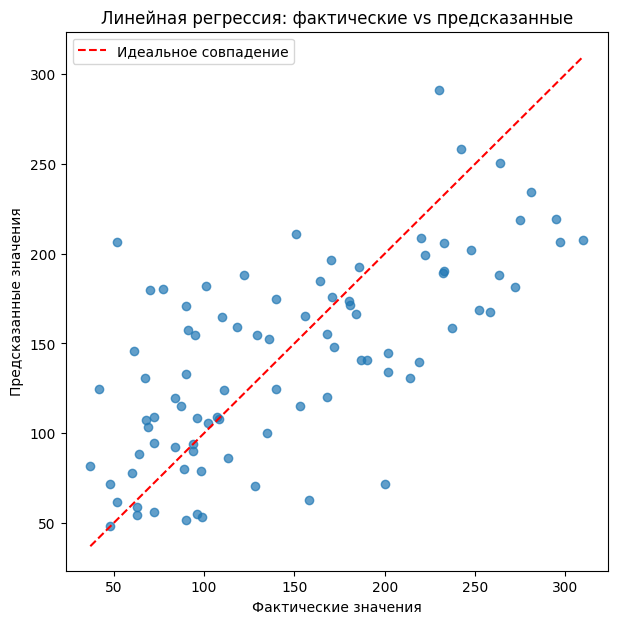

In [31]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--",
    label="Идеальное совпадение",
)
plt.xlabel("Фактические значения")
plt.ylabel("Предсказанные значения")
plt.title("Линейная регрессия: фактические vs предсказанные")
plt.legend()
plt.show()


## Вывод

По текущему запуску получены значения `MSE = 2900.19`, `MAE = 42.79`, `MAPE = 0.375`, `R^2 = 0.453`.
Модель объясняет около `45.3 %` вариации `target`.

Наибольшие по модулю коэффициенты соответствуют признакам `s1`, `s5`, `bmi`, `s2` и `bp`.
Это означает, что именно эти признаки дают самый заметный вклад в итоговый прогноз в рамках линейной модели.

Качество соответствует умеренному уровню. График `фактические vs предсказанные` и значение `R^2`
показывают, что линейная зависимость объясняет только часть структуры данных.
